# 17. New College Multi-Sensor Pipeline Example

This notebook mirrors the New College data import and ground-truth frame handling from notebook 15, then rebuilds the rolling calibration example with the new `multi_sensor_pipeline` package.

The structure is intentionally modular: definitions, imports, data preparation, stream construction, measurement plotting, graph solving, and result plotting are kept in separate cells so each ownership boundary is visible.


## 1. Definitions

Only plain Python values live here. Imports and conversion to `Path`/`numpy` objects happen in the next cells, keeping configuration easy to copy into other notebooks.


In [1]:
# Dataset and output controls copied from notebook 15.
DATASET_ROOT_TEXT = '/mnt/d/Downloads/MobRobLab/NewCollegeDataset/01_short_experiment'
LIDAR_ODOMETRY_CSV_TEXT = '~/Skoltech/phd_proposal/data/NewCollegeDataset/lidar_odometry.csv'
OUTPUT_SUBDIR = 'notebook17_multi_sensor_pipeline'
SAVE_FIGURES = True

# Real sensor import controls.
TARGET_IMU_FREQUENCY_HZ = 100.0
MAX_IMU_FILES = None
LIDAR_SCAN_PERIOD_S = None
INVERT_IMPORTED_LIDAR_MEASUREMENTS = False
FIXED_EXTRINSIC = 'T_B_L'

# Initial-guess controls. These are estimator guesses, not ground truth.
T_B_I_ESTIMATE_INITIAL_LIST = [
    [1.0, 0.0, 0.0, 0.0],
    [0.0, 1.0, 0.0, 0.0],
    [0.0, 0.0, 1.0, 0.0],
    [0.0, 0.0, 0.0, 1.0],
]
T_B_L_ESTIMATE_INITIAL_LIST = [
    [1.0, 0.0, 0.0, 0.0],
    [0.0, 1.0, 0.0, 0.0],
    [0.0, 0.0, 1.0, 0.0],
    [0.0, 0.0, 0.0, 1.0],
]
BIAS_ESTIMATE_INITIAL_LIST = [0.0, 0.0, 0.0]
TAU_I_ESTIMATE_INITIAL = 2.0
TAU_L_ESTIMATE_INITIAL = 0.0

# Rolling factor-graph controls. Notebook 15 used WINDOW_SIZE * 10 and half-window steps.
WINDOW_SIZE = 5.0
STEP_SIZE = 1.0
ROLLING_WINDOW_SIZE = WINDOW_SIZE * 10.0
ROLLING_STEP_SIZE = ROLLING_WINDOW_SIZE / 2.0
IMU_SAMPLES_PER_FACTOR = None
LIDAR_SAMPLES_PER_FACTOR = None
FACTOR_GRAPH_METHOD = 'LM'
ACC_MODE = 'complex'
IMU_TIME_OFFSET_MARGIN = 2.5 * 2.0
LIDAR_TIME_OFFSET_MARGIN = 2.5 * 2.0

# Imported-data noise/linearization assumptions.
STATIONARY_SAMPLES = 1000
GYRO_NOISE_FLOOR = 1e-6
ACCEL_NOISE_FLOOR = 1e-6
LIDAR_INFORMATION_SCALE = 1e-2

# Solver and prior settings copied in spirit from notebook 15.
# IMU_PRIOR_SOURCE controls only the soft prior target. With 'optimized',
# the first window falls back to the configured prior_value and later windows
# use the previous rolling-window solution as the prior target.
SOLVER_SCHEDULER = [(1e-5, 100), (1e-5, 100), (1e-9, 100)]
GRAVITY_WORLD_LIST = [0.0, 0.0, 9.81]
T_B_I_PRIOR_INFORMATION_DIAG = [1e1, 1e1, 1e1, 1e3, 1e3, 1e3]
TAU_I_PRIOR_INFORMATION = 1e2
BIAS_PRIOR_INFORMATION = 1e5
GYRO_INFORMATION = 1e0
ACCEL_INFORMATION = 1e0
IMU_PRIOR_SOURCE = 'optimized'  # alternatives supported by VariableConfig: 'constant', 'numerical', 'default'


## 2. Imports

The old modules are imported for dataset loading, frame conversion, and trajectory initialization. The new pipeline imports are grouped separately.


In [2]:
from pathlib import Path
import sys

ROOT = Path.cwd()
for candidate in (ROOT, *ROOT.parents):
    if (candidate / 'src' / 'multi_sensor_pipeline').exists():
        ROOT = candidate
        break
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

OUT = ROOT / 'outputs' / OUTPUT_SUBDIR
OUT.mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import mrob
import numpy as np
import pandas as pd
from IPython.display import display

import data_processing
import transform
from new_college_dataset import load_imus
from new_college_dataset.data import import_true_trajectory
from new_college_dataset.lidar import load_lidar_data_csv
from calib_observability.backend import estimate_poses_dummy
from calib_observability.simulation import reframe_dataset_to_fixed_extrinsic
from calib_observability.workflows import build_dataset_from_imported_sensor_streams

from multi_sensor_pipeline import (
    ComplexAccelStream,
    GyroStream,
    LidarOdometryStream,
    RollingGraph,
    Sensor,
    SimpleAccelStream,
    SolverConfig,
    TrajectoryConfig,
    VariableConfig,
    VariableKey,
    VariableType,
    plot_calibration_estimates,
    plot_rolling_trajectory,
    plot_stream_measurements,
    print_rolling_result_summary,
)

DATASET_ROOT = Path(DATASET_ROOT_TEXT)
LIDAR_ODOMETRY_CSV = Path(LIDAR_ODOMETRY_CSV_TEXT).expanduser()
T_B_I_ESTIMATE_INITIAL = np.asarray(T_B_I_ESTIMATE_INITIAL_LIST, dtype=float)
T_B_L_ESTIMATE_INITIAL = np.asarray(T_B_L_ESTIMATE_INITIAL_LIST, dtype=float)
BIAS_ESTIMATE_INITIAL = np.asarray(BIAS_ESTIMATE_INITIAL_LIST, dtype=float)
GRAVITY_WORLD = np.asarray(GRAVITY_WORLD_LIST, dtype=float)


## 3. Helper Definitions

These small helpers are copied from the notebook 15 workflow where they are specific to the New College imported data layout.


In [3]:
def lidar_scan_timestamps_for_pipeline(lidar_data):
    if lidar_data.scan_timestamps_s is not None:
        return np.asarray(lidar_data.scan_timestamps_s, dtype=float)
    midpoint_times = np.asarray(lidar_data.timestamps_s, dtype=float)
    if midpoint_times.size == 0:
        raise ValueError('LiDAR data has no timestamps')
    if midpoint_times.size == 1:
        if LIDAR_SCAN_PERIOD_S is None:
            raise ValueError('Set LIDAR_SCAN_PERIOD_S when only one LiDAR midpoint timestamp is available')
        half_period = 0.5 * float(LIDAR_SCAN_PERIOD_S)
        return np.array([midpoint_times[0] - half_period, midpoint_times[0] + half_period], dtype=float)
    boundaries = np.empty(midpoint_times.size + 1, dtype=float)
    boundaries[1:-1] = 0.5 * (midpoint_times[:-1] + midpoint_times[1:])
    boundaries[0] = midpoint_times[0] - (boundaries[1] - midpoint_times[0])
    boundaries[-1] = midpoint_times[-1] + (midpoint_times[-1] - boundaries[-2])
    return boundaries


def accumulate_lidar_poses(relative_poses):
    poses = np.empty((len(relative_poses) + 1, 4, 4), dtype=float)
    poses[0] = np.eye(4)
    for measurement_index, relative_pose in enumerate(relative_poses):
        poses[measurement_index + 1] = poses[measurement_index] @ relative_pose
    return poses


def result_table(results):
    rows = []
    for result in results:
        row = {
            'window': result.window_index,
            'start': result.window_start,
            'end': result.window_end,
            'chi2_before': result.chi2_before,
            'chi2_after': result.chi2_after,
            'factors': sum(result.factor_counts.values()),
        }
        for key, value in result.calibration_values.items():
            if key.variable_type == VariableType.TIME_OFFSET:
                row[key.label] = float(value)
        rows.append(row)
    return pd.DataFrame(rows)


## 4. New College Data Import

This section follows notebook 15: load the real Realsense IMU, load the precomputed LiDAR odometry CSV, estimate simple noise proxies, and build the imported dataset object used for consistent frames and references.


In [4]:
imu_streams_raw = load_imus(
    DATASET_ROOT / 'raw_format' / 'realsense_imu',
    target_frequency_hz=TARGET_IMU_FREQUENCY_HZ,
    max_files=MAX_IMU_FILES,
)
primary_imu_name = list(imu_streams_raw.keys())[0]
primary_imu = imu_streams_raw[primary_imu_name]

lidar_data = load_lidar_data_csv(LIDAR_ODOMETRY_CSV)
velocity_timestamps = lidar_data.scan_timestamps_s if lidar_data.scan_timestamps_s is not None else lidar_data.timestamps_s
lidar_angvel_radps = transform.relative_se3_to_angvels(lidar_data.relative_poses_se3, velocity_timestamps)
lidar_velocity_mps = transform.relative_se3_to_velocities(lidar_data.relative_poses_se3, velocity_timestamps)
lidar_noise = np.hstack((
    np.std(lidar_angvel_radps[:STATIONARY_SAMPLES], axis=0),
    np.std(lidar_velocity_mps[:STATIONARY_SAMPLES], axis=0),
))
lidar_noise = np.maximum(lidar_noise, 1e-6)

print('Primary IMU:', primary_imu_name, primary_imu.timestamps_s.shape)
print('LiDAR relative poses:', lidar_data.relative_poses_se3.shape)
print('LiDAR noise proxy:', lidar_noise)


Primary IMU: realsense_imu_data (153017,)
LiDAR relative poses: (15300, 4, 4)
LiDAR noise proxy: [0.05586253 0.05452688 0.11648389 0.33788636 0.38617523 0.11934804]


## 5. Dataset Frames And Properly Rotated Ground Truth

The body/LiDAR/Realsense transforms and ground-truth rotation are copied from notebook 15. The final `true_poses` trajectory is expressed in the LiDAR-world convention used by the LiDAR odometry pipeline.


In [5]:
T_L_OUSTER_INITIAL = np.array([[-1, 0, 0, -0.006253], [0, -1, 0, 0.011775], [0, 0, 1, -0.028535], [0, 0, 0, 1]])
T_C0_OUSTER_INITIAL = np.array([[ 0.70992163, -0.70414167,  0.01399269,  0.01562753],
                                [ 0.02460003,  0.00493623, -0.99968519, -0.01981648],
                                [ 0.70385092,  0.71004236,  0.02082624, -0.07544143],
                                [ 0.,          0.,          0.,          1.        ]])
T_C0_REALSENSE_INITIAL = np.array([[ 0.99999395,  0.00301154,  0.00174074,  0.0058566 ],
                                   [-0.00301404,  0.99999443,  0.00143592,  0.01737982],
                                   [-0.00173641, -0.00144116,  0.99999745, -0.01595566],
                                   [ 0.,          0.,          0.,          1.        ]])
T_OUSTER_REALSENSE_INITIAL = np.linalg.inv(T_C0_OUSTER_INITIAL) @ T_C0_REALSENSE_INITIAL
T_B_I_INITIAL_FOR_DATASET = T_L_OUSTER_INITIAL @ T_OUSTER_REALSENSE_INITIAL
T_B_I_INITIAL_TANGENT = mrob.SE3(T_B_I_INITIAL_FOR_DATASET).Ln()
T_B_L_INITIAL_TANGENT = np.zeros(6, dtype=float)
GYRO_BIAS_INITIAL_FOR_DATASET = np.zeros(3, dtype=float)
TAU_I_WEBSITE_REFERENCE = 0.056010849
TAU_I_NUMERICAL_REFERENCE = 0.11101
TAU_I_INITIAL_FOR_DATASET = TAU_I_NUMERICAL_REFERENCE
TAU_L_INITIAL_FOR_DATASET = 0.0

if lidar_data.scan_timestamps_s is not None and len(lidar_data.scan_timestamps_s) > 1:
    LIDAR_RATE_HZ = 1.0 / float(np.median(np.diff(lidar_data.scan_timestamps_s)))
elif len(lidar_data.timestamps_s) > 1:
    LIDAR_RATE_HZ = 1.0 / float(np.median(np.diff(lidar_data.timestamps_s)))
elif LIDAR_SCAN_PERIOD_S is not None:
    LIDAR_RATE_HZ = 1.0 / float(LIDAR_SCAN_PERIOD_S)
else:
    LIDAR_RATE_HZ = 5.0

IMPORTED_GYRO_NOISE_STD_RADPS = max(float(np.max(np.std(primary_imu.gyro_radps[:STATIONARY_SAMPLES], axis=0))), GYRO_NOISE_FLOOR)
IMPORTED_ACCEL_NOISE_STD_MPS2 = max(float(np.max(np.std(primary_imu.accel_mps2[:STATIONARY_SAMPLES], axis=0))), ACCEL_NOISE_FLOOR)
IMPORTED_LIDAR_POSE_NOISE_STD = lidar_noise

lidar_scan_timestamps_s = lidar_scan_timestamps_for_pipeline(lidar_data)
raw_dataset = build_dataset_from_imported_sensor_streams(
    imu_timestamps=primary_imu.timestamps_s,
    gyroscope=primary_imu.gyro_radps,
    accelerometer=primary_imu.accel_mps2,
    lidar_scan_timestamps=lidar_scan_timestamps_s,
    lidar_relative_poses=lidar_data.relative_poses_se3,
    T_B_I_initial_tangent=T_B_I_INITIAL_TANGENT,
    T_B_L_initial_tangent=T_B_L_INITIAL_TANGENT,
    gyro_bias_initial=GYRO_BIAS_INITIAL_FOR_DATASET,
    tau_I_initial=TAU_I_INITIAL_FOR_DATASET,
    tau_L_initial=TAU_L_INITIAL_FOR_DATASET,
    gyro_noise_std=IMPORTED_GYRO_NOISE_STD_RADPS,
    accel_noise_std=IMPORTED_ACCEL_NOISE_STD_MPS2,
    lidar_pose_noise_std=IMPORTED_LIDAR_POSE_NOISE_STD,
    invert_lidar_measurements=INVERT_IMPORTED_LIDAR_MEASUREMENTS,
    true_poses_path=DATASET_ROOT / 'ground_truth/registered_poses.csv',
)
dataset = reframe_dataset_to_fixed_extrinsic(raw_dataset, FIXED_EXTRINSIC)
pose_provider = estimate_poses_dummy(dataset)

T_B_C0 = np.array([
    [ 0.,  0.,  1., 0.],
    [-1.,  0.,  0., 0.],
    [ 0., -1.,  0., 0.],
    [ 0.,  0.,  0., 1.],
])
T_B_L_WORLD = T_B_C0 @ T_C0_OUSTER_INITIAL @ np.linalg.inv(T_L_OUSTER_INITIAL)
true_timestamps, true_trajectory = import_true_trajectory(DATASET_ROOT / 'ground_truth/registered_poses.csv')
true_trajectory = transform.transform_se3s(true_trajectory, np.linalg.inv(T_B_L_WORLD))
true_trajectory = transform.transform_se3s(true_trajectory, T_B_L_WORLD, left=False)
true_poses = true_trajectory
pose_timestamps = true_timestamps

original_imu_timestamps = dataset.imu.sensor_timestamps.copy()
original_gyrs = dataset.imu.gyroscope.copy()
original_accs = dataset.imu.accelerometer.copy()
lidar_timestamps = dataset.lidar.sensor_timestamps.copy()
lidar_poses = accumulate_lidar_poses(dataset.lidar.measurements)

T_B_I_REFERENCE = dataset.T_B_I_true.copy()
TAU_I_REFERENCE = float(dataset.tau_I_true)
BIAS_REFERENCE = dataset.gyro_bias_true.copy()
T_B_L_REFERENCE = dataset.T_B_L_true.copy()
TAU_L_REFERENCE = float(dataset.tau_L_true)

print({
    'dataset_start': dataset.start_time,
    'dataset_end': dataset.end_time,
    'imu_samples': len(dataset.imu.sensor_timestamps),
    'lidar_measurements': len(dataset.lidar.measurements),
    'fixed_extrinsic': FIXED_EXTRINSIC,
    'lidar_rate_hz_estimate': LIDAR_RATE_HZ,
})
print('reference tau_I:', TAU_I_REFERENCE)
print('reference T_B_I Ln:', mrob.SE3(T_B_I_REFERENCE).Ln())


{'dataset_start': 1583836591.182591, 'dataset_end': 1583838121.1563556, 'imu_samples': 152978, 'lidar_measurements': 15298, 'fixed_extrinsic': 'T_B_L', 'lidar_rate_hz_estimate': 9.9996280808495}
reference tau_I: 0.11101
reference T_B_I Ln: [-0.70217089 -1.74329767  1.7650715  -0.10388228  0.04898033 -0.00375577]


## 6. Create Pipeline Sensors, Streams, Variables, And RollingGraph

The physical IMU owns one shared extrinsic, one shared time offset, and one shared gyro-bias node. The gyro and accelerometer streams request the same IMU variables, while the LiDAR odometry stream requests the LiDAR variables.


In [6]:
imu = Sensor('imu_0', kind='imu')
lidar = Sensor('lidar_0', kind='lidar')

gyro_stream = GyroStream(
    sensor=imu,
    timestamps=original_imu_timestamps,
    angular_velocity=original_gyrs,
    samples_per_factor=IMU_SAMPLES_PER_FACTOR,
    time_offset_margin=IMU_TIME_OFFSET_MARGIN,
    information=GYRO_INFORMATION,
)

if ACC_MODE == 'complex':
    accel_stream = ComplexAccelStream(
        sensor=imu,
        timestamps=original_imu_timestamps,
        acceleration=original_accs,
        angular_velocity=original_gyrs,
        samples_per_factor=IMU_SAMPLES_PER_FACTOR,
        time_offset_margin=IMU_TIME_OFFSET_MARGIN,
        gravity_world=GRAVITY_WORLD,
        information=ACCEL_INFORMATION,
    )
else:
    accel_stream = SimpleAccelStream(
        sensor=imu,
        timestamps=original_imu_timestamps,
        acceleration=original_accs,
        samples_per_factor=IMU_SAMPLES_PER_FACTOR,
        time_offset_margin=IMU_TIME_OFFSET_MARGIN,
        gravity_world=GRAVITY_WORLD,
        information=ACCEL_INFORMATION,
    )

lidar_stream = LidarOdometryStream(
    sensor=lidar,
    timestamps=lidar_timestamps,
    odometry_poses=lidar_poses,
    samples_per_factor=LIDAR_SAMPLES_PER_FACTOR,
    time_offset_margin=LIDAR_TIME_OFFSET_MARGIN,
    information=LIDAR_INFORMATION_SCALE * np.diag(1.0 / lidar_noise**2),
)

streams = [gyro_stream, accel_stream, lidar_stream]

imu_extrinsic_key = VariableKey('imu_0', VariableType.EXTRINSIC)
imu_tau_key = VariableKey('imu_0', VariableType.TIME_OFFSET)
imu_bias_key = VariableKey('imu_0', VariableType.GYRO_BIAS)
lidar_extrinsic_key = VariableKey('lidar_0', VariableType.EXTRINSIC)
lidar_tau_key = VariableKey('lidar_0', VariableType.TIME_OFFSET)

imu_prior_source = IMU_PRIOR_SOURCE
variable_configs = {
    imu_extrinsic_key: VariableConfig(
        initial_source='optimized',
        initial_value=T_B_I_INITIAL_FOR_DATASET,
        fixed=False,
        prior_source=imu_prior_source,
        prior_value=T_B_I_INITIAL_FOR_DATASET,
        prior_information=np.diag(T_B_I_PRIOR_INFORMATION_DIAG),
    ),
    imu_tau_key: VariableConfig(
        initial_source='optimized',
        initial_value=TAU_I_ESTIMATE_INITIAL,
        fixed=False,
        prior_source=imu_prior_source,
        prior_value=TAU_I_ESTIMATE_INITIAL,
        prior_information=TAU_I_PRIOR_INFORMATION,
    ),
    imu_bias_key: VariableConfig(
        initial_source='optimized',
        initial_value=BIAS_ESTIMATE_INITIAL,
        fixed=False,
        prior_source='constant',
        prior_value=BIAS_ESTIMATE_INITIAL,
        prior_information=BIAS_PRIOR_INFORMATION,
    ),
    lidar_extrinsic_key: VariableConfig(
        initial_source='constant',
        initial_value=T_B_L_ESTIMATE_INITIAL,
        fixed=True,
    ),
    lidar_tau_key: VariableConfig(
        initial_source='constant',
        initial_value=TAU_L_ESTIMATE_INITIAL,
        fixed=True,
    ),
}

rolling_graph = RollingGraph(
    streams=streams,
    sensors=[imu, lidar],
    variable_configs=variable_configs,
    solver_config=SolverConfig(
        method=FACTOR_GRAPH_METHOD,
        scheduler=SOLVER_SCHEDULER,
        solver_verbose=False,
    ),
    trajectory_config=TrajectoryConfig(
        anchor_first_pose=True,
        anchor_first_pose_each_window=True,
        anchor_last_pose=False,
        anchor_all_poses=False,
        use_imu_gyr=False,
    ),
)

pd.DataFrame([
    {'stream': stream.stream_name, 'type': stream.stream_type, 'sensor': stream.sensor.sensor_id, 'requirements': [req.key.label for req in stream.required_variables()]}
    for stream in streams
])


,stream,type,sensor,requirements
0,imu_0.gyro,gyro,imu_0,"[imu_0:extrinsic, imu_0:time_offset, imu_0:gyr..."
1,imu_0.complex_accel,complex_accel,imu_0,"[imu_0:extrinsic, imu_0:time_offset, imu_0:gyr..."
2,lidar_0.odometry,lidar_odometry,lidar_0,"[lidar_0:extrinsic, lidar_0:time_offset]"


## 7. Plot Measurements From The Pipeline Stream Objects

These plots read directly from the `GyroStream`, `ComplexAccelStream`/`SimpleAccelStream`, and `LidarOdometryStream` objects that will produce graph factors.


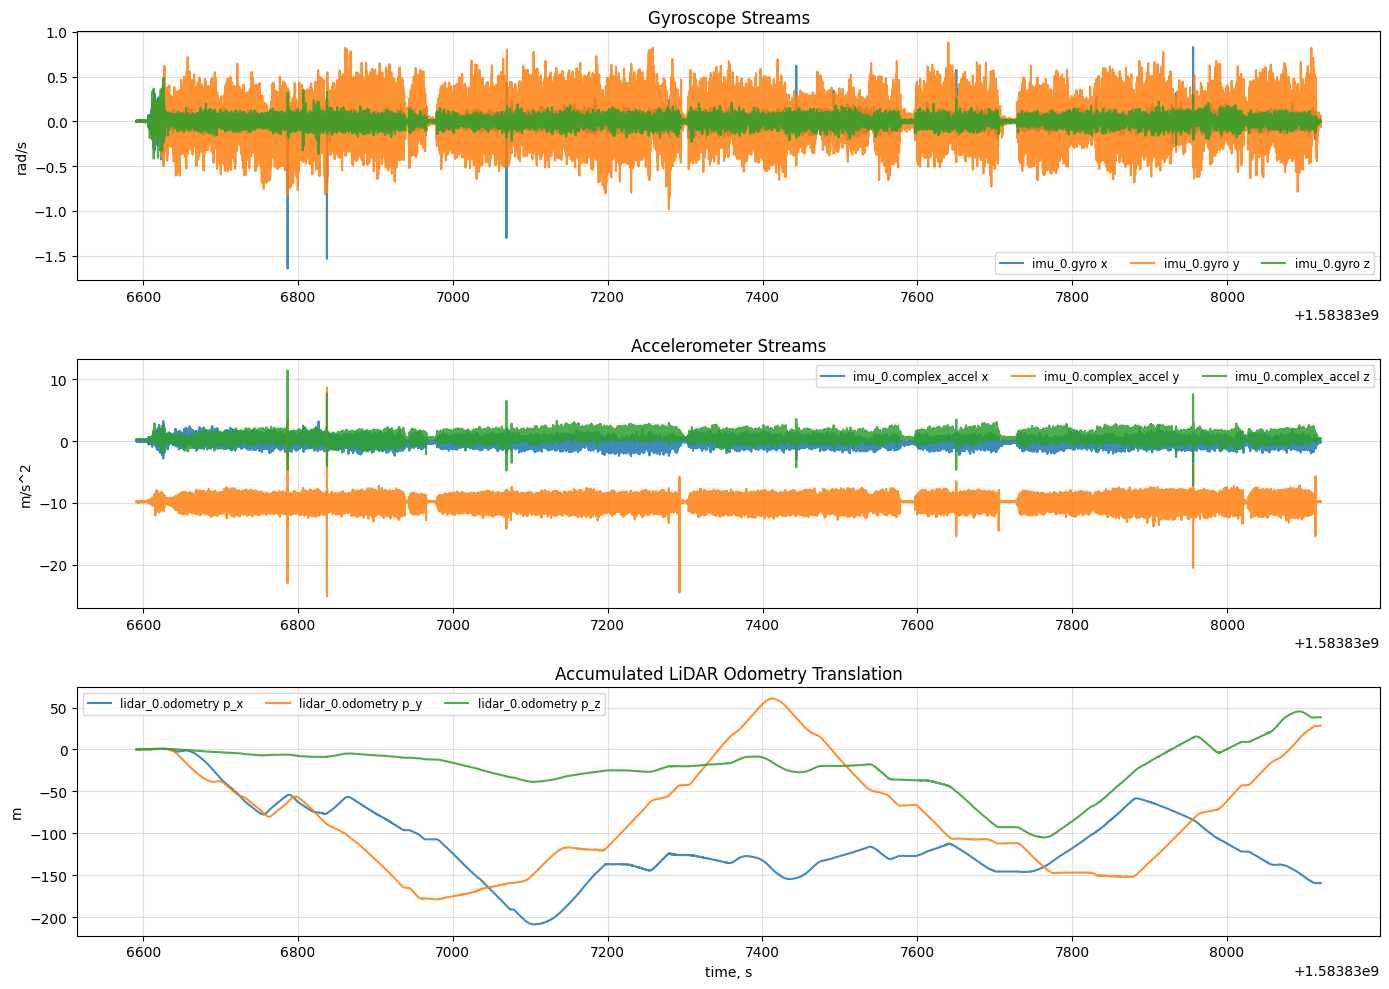

In [7]:
fig, axes = plot_stream_measurements(streams)
if SAVE_FIGURES:
    fig.savefig(OUT / 'pipeline_stream_measurements.png', dpi=160)
plt.show()
plt.close(fig)


## 8. Initialize The Trajectory

The initialization path reuses the existing `data_processing._initialize_trajectory_poses` helper, just as notebook 15 did. The new pipeline will also reuse this helper internally whenever it needs to propagate missing poses.


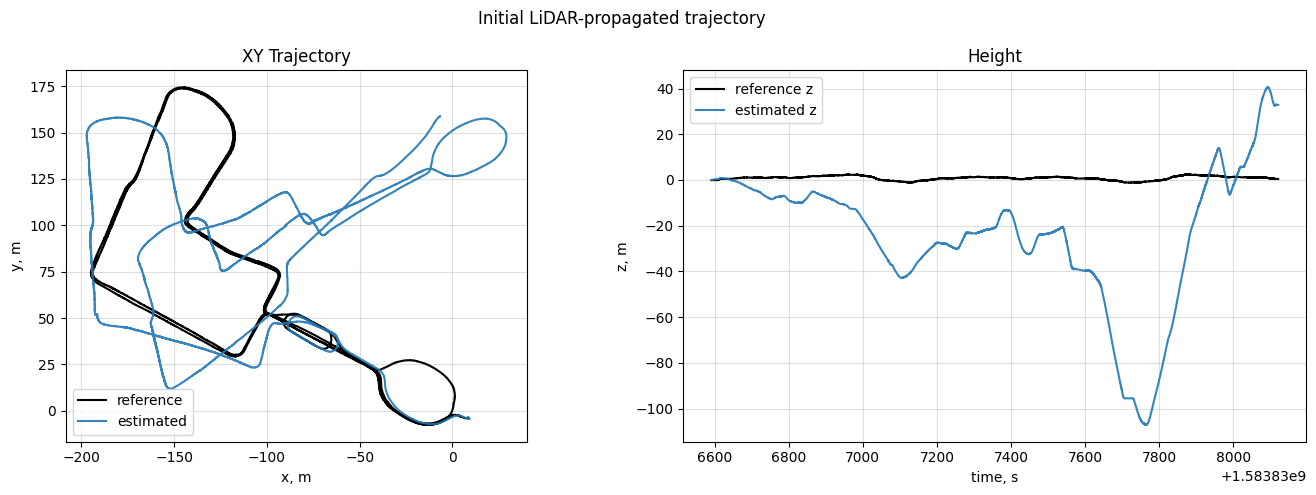

In [8]:
pose_slice = slice(5, -5)
window_pose_timestamps = pose_timestamps[pose_slice]
init_lidar_poses = data_processing._initialize_trajectory_poses(
    pose_timestamps=window_pose_timestamps,
    states=[true_poses[5]],
    first_pose=true_poses[5],
    imu_timestamps=original_imu_timestamps,
    angular_velocity_imu=original_gyrs,
    T_B_I_initial=T_B_I_INITIAL_FOR_DATASET,
    bias_initial=BIAS_ESTIMATE_INITIAL,
    tau_I_initial=TAU_I_ESTIMATE_INITIAL,
    lidar_timestamps=lidar_timestamps,
    lidar_odometry_poses=lidar_poses,
    T_B_L_initial=T_B_L_ESTIMATE_INITIAL,
    tau_L_initial=TAU_L_ESTIMATE_INITIAL,
)

fig, axes = plot_rolling_trajectory(
    window_pose_timestamps,
    init_lidar_poses,
    reference_timestamps=window_pose_timestamps,
    reference_poses=true_poses[pose_slice],
    title='Initial LiDAR-propagated trajectory',
)
if SAVE_FIGURES:
    fig.savefig(OUT / 'initial_lidar_trajectory.png', dpi=160)
plt.show()
plt.close(fig)


## 9. Solve The Rolling Graph

`RollingGraph` now owns orchestration only: it creates trajectory nodes, resolves shared calibration variables, adds priors, asks each stream to add factors, solves, and updates `RollingState`.


In [9]:
results = rolling_graph.generate_filter_iterative(
    window_size=ROLLING_WINDOW_SIZE,
    step_size=ROLLING_STEP_SIZE,
    pose_timestamps=window_pose_timestamps,
    states=init_lidar_poses,
    first_pose=init_lidar_poses[0],
    clear_previous=True,
    verbose=0,
)

estimated_timestamps, estimated_poses = rolling_graph.rolling_state.rolling_trajectory
print(f'accelerometer mode: {ACC_MODE}')
print(f'solved windows: {len(results)}')
print(f'stitched estimated poses: {estimated_poses.shape}')
if results:
    print_rolling_result_summary(results[-1])


accelerometer mode: complex
solved windows: 60
stitched estimated poses: (15197, 4, 4)
window 59: [1583838071.383, 1583838116.044]
poses: 446
chi2: 7.759832e+03 -> 1.523409e-01
factor counts: {'gyro_calib_prop': 445, 'accel_lever_arm_calib': 444, 'lidar_calib_odometry': 445, 'extrinsic_prior': 1, 'gyro_bias_prior': 1, 'time_offset_prior': 1}
imu_0:extrinsic Ln: [-0.72363476 -1.80538719  1.72417728 -0.10066708  0.04943791 -0.00837185]
imu_0:gyro_bias: [-5.70239687e-08  3.21122758e-07  7.10068566e-08]
imu_0:time_offset: 2.083749450854064
lidar_0:extrinsic Ln: [-0.  0. -0.  0.  0.  0.]
lidar_0:time_offset: 0.0


## 10. Inspect Rolling Results And Constructed Metadata

The metadata is intentionally visualization-neutral: it describes nodes, variables, streams, factors, and priors without depending on graph drawing libraries.


In [10]:
display(result_table(results).tail())

metadata = rolling_graph.metadata
print('trajectory nodes in last graph:', len(metadata.trajectory_nodes))
print('calibration variables in last graph:', len(metadata.calibration_variables))
print('factors in last graph:', len(metadata.factors))
print('priors in last graph:', len(metadata.priors))
print('last graph factor counts:', metadata.factor_counts)

pd.DataFrame([
    {
        'key': variable.key.label,
        'node_id': variable.node_id,
        'fixed': variable.fixed,
        'initial_source': variable.initial_source.value,
    }
    for variable in metadata.calibration_variables
])


,window,start,end,chi2_before,chi2_after,factors,imu_0:time_offset,lidar_0:time_offset
55,55,1.583838e+09,1.583838e+09,23944.345181,0.299448,1499,2.078328,0.0
56,56,1.583838e+09,1.583838e+09,12634.005602,0.207760,1499,2.081789,0.0
57,57,1.583838e+09,1.583838e+09,26099.474174,0.217756,1499,2.084838,0.0
58,58,1.583838e+09,1.583838e+09,9753.689147,0.216918,1499,2.083694,0.0
59,59,1.583838e+09,1.583838e+09,7759.831537,0.152341,1337,2.083749,0.0


trajectory nodes in last graph: 446
calibration variables in last graph: 5
factors in last graph: 1334
priors in last graph: 3
last graph factor counts: {'gyro_calib_prop': 445, 'accel_lever_arm_calib': 444, 'lidar_calib_odometry': 445, 'extrinsic_prior': 1, 'gyro_bias_prior': 1, 'time_offset_prior': 1}


,key,node_id,fixed,initial_source
0,imu_0:extrinsic,446,False,optimized
1,imu_0:gyro_bias,447,False,optimized
2,imu_0:time_offset,448,False,optimized
3,lidar_0:extrinsic,449,True,constant
4,lidar_0:time_offset,450,True,constant


## 11. Plot The Resulting Trajectory

The stitched rolling output is plotted against the properly rotated New College ground-truth trajectory and the LiDAR-propagated initialization.


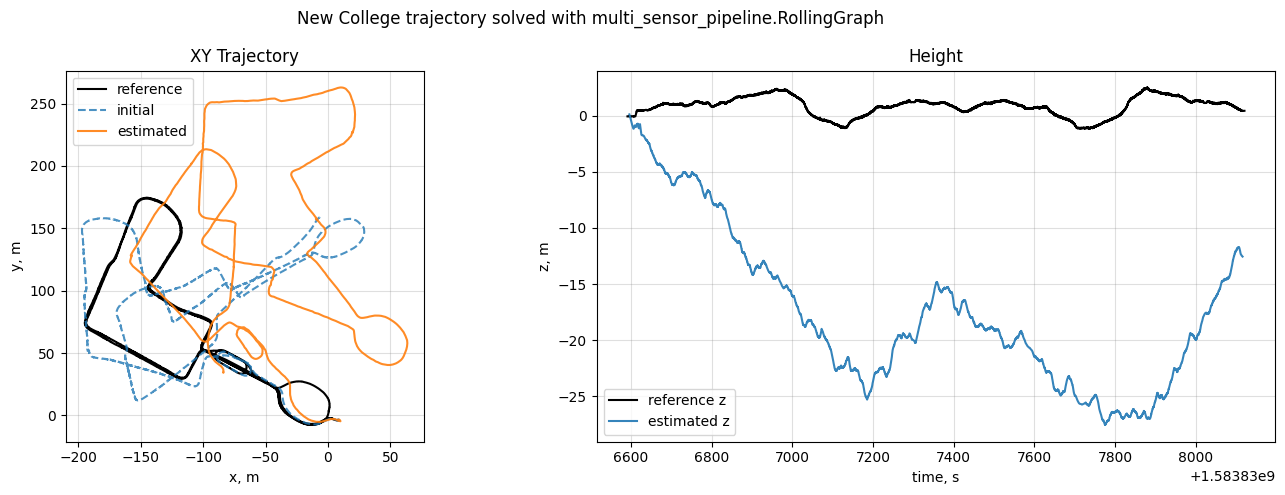

In [11]:
fig, axes = plot_rolling_trajectory(
    estimated_timestamps,
    estimated_poses,
    reference_timestamps=window_pose_timestamps,
    reference_poses=true_poses[pose_slice],
    initial_poses=init_lidar_poses,
    title='New College trajectory solved with multi_sensor_pipeline.RollingGraph',
)
if SAVE_FIGURES:
    fig.savefig(OUT / 'rolling_graph_trajectory_result.png', dpi=160)
plt.show()
plt.close(fig)


## 12. Plot Calibration Variables Over Time

The IMU extrinsic, IMU time offset, IMU gyro bias, fixed LiDAR extrinsic, and fixed LiDAR time offset all come from the new `WindowResult.calibration_values` dictionary keyed by `VariableKey`.


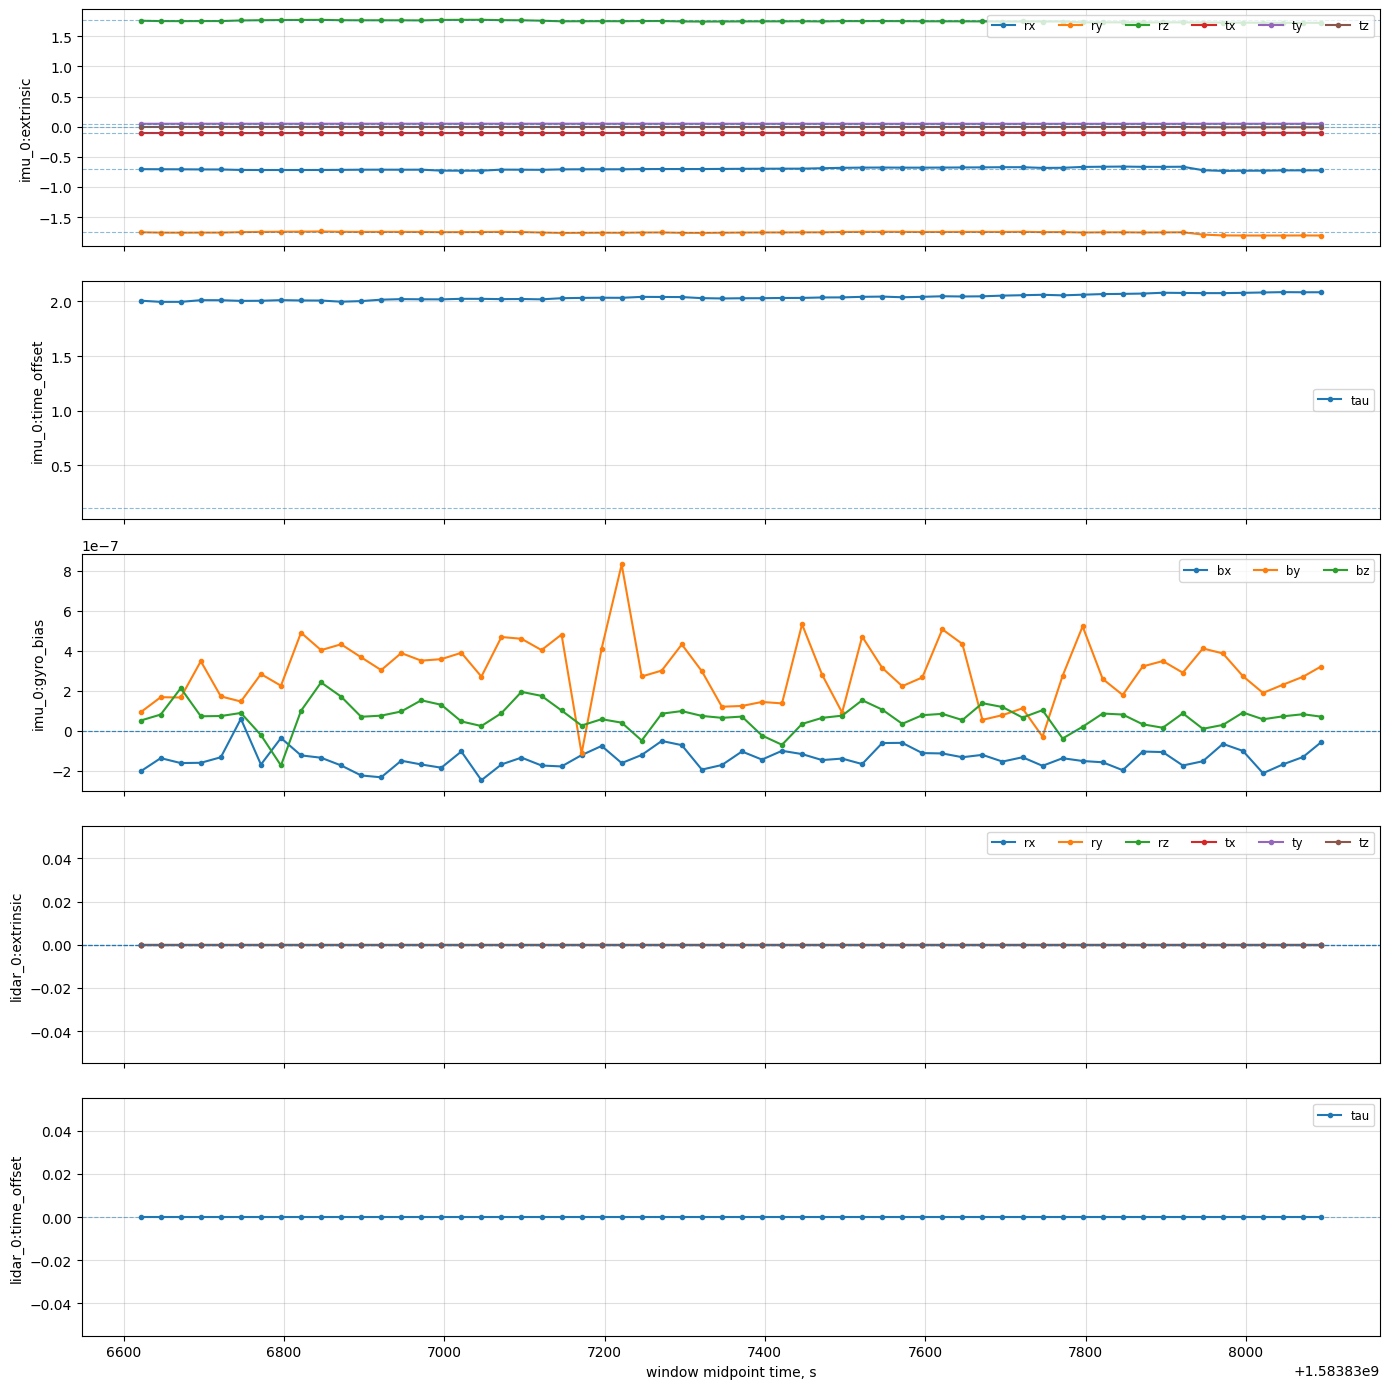

In [12]:
calibration_keys = [
    imu_extrinsic_key,
    imu_tau_key,
    imu_bias_key,
    lidar_extrinsic_key,
    lidar_tau_key,
]
reference_values = {
    imu_extrinsic_key: T_B_I_REFERENCE,
    imu_tau_key: TAU_I_REFERENCE,
    imu_bias_key: BIAS_REFERENCE,
    lidar_extrinsic_key: T_B_L_REFERENCE,
    lidar_tau_key: TAU_L_REFERENCE,
}

fig, axes = plot_calibration_estimates(results, calibration_keys, reference_values=reference_values)
if SAVE_FIGURES:
    fig.savefig(OUT / 'rolling_graph_calibration_variables.png', dpi=160)
plt.show()
plt.close(fig)


## 13. Notes

- Gyro and accelerometer streams both reference `imu_0`, so they share `imu_0:extrinsic` and `imu_0:time_offset` nodes.
- Initial values and priors are configured separately through `VariableConfig`.
- `IMU_PRIOR_SOURCE = 'optimized'` makes the first IMU soft prior fall back to the configured `prior_value`, then uses the previous rolling-window calibration estimate as the prior target in later windows. Set it to `'numerical'` to use cached numerical calibration as the prior source instead.
- The graph metadata is ready for a future visualizer, but this notebook intentionally does not implement graph visualization.
